## Extracting data from the BiMMuDA dataset

In [1]:
import os
import shutil

source_root = "data/BiMMuDA"
destination = "all_midis"

os.makedirs(destination, exist_ok=True)

for root, dirs, files in os.walk(source_root):
    for file in files:
        if file.endswith(".mid"):
            src_path = os.path.join(root, file)
            dst_path = os.path.join(destination, file)
            shutil.copy2(src_path, dst_path)

In [ ]:
import os
import mido
import shutil

SOURCE_DIR = "all_midis"
DEST_DIR = "clean_monophonic_midis"

os.makedirs(DEST_DIR, exist_ok=True)

def is_monophonic(midi_path):
    try:
        midi = mido.MidiFile(midi_path)
    except Exception:
        return False, "corrupted"

    notes = []
    current_time = 0

    for track in midi.tracks:
        current_time = 0
        active_notes = {}

        for msg in track:
            current_time += msg.time

            if msg.type == "note_on" and msg.velocity > 0 and msg.channel != 9:
                active_notes[msg.note] = current_time

            elif (msg.type == "note_off") or (msg.type == "note_on" and msg.velocity == 0):
                if msg.note in active_notes:
                    start = active_notes.pop(msg.note)
                    end = current_time
                    notes.append((start, end))

    if len(notes) == 0:
        return False, "no_notes"

    # sort by start time
    notes.sort(key=lambda x: x[0])

    # check overlap
    prev_end = notes[0][1]
    for start, end in notes[1:]:
        if start < prev_end:
            return False, "polyphonic"
        prev_end = max(prev_end, end)

    return True, "monophonic"


print("Cleaning MIDI dataset for IDyOM...\n")

for file in os.listdir(SOURCE_DIR):
    if file.endswith(".mid"):
        
        # Skip files containing "full"
        if "full" in file.lower():
            print(f"Skipping {file} → contains 'full'")
            continue
        
        path = os.path.join(SOURCE_DIR, file)
        ok, reason = is_monophonic(path)

        if ok:
            shutil.copy2(path, os.path.join(DEST_DIR, file))
        else:
            print(f"Skipping {file} → {reason}")

print("\nDone.")

Cleaning MIDI dataset for IDyOM...

Skipping 2006_01_full.mid → contains 'full'
Skipping 1980_04_full.mid → contains 'full'
Skipping 1980_05_full.mid → contains 'full'
Skipping 1996_02_full.mid → contains 'full'
Skipping 1996_03_full.mid → contains 'full'
Skipping 1958_01_full.mid → contains 'full'
Skipping 2023_05_full.mid → contains 'full'
Skipping 2023_04_full.mid → contains 'full'
Skipping 1953_05_full.mid → contains 'full'
Skipping 1953_04_full.mid → contains 'full'
Skipping 1976_01_full.mid → contains 'full'
Skipping 2011_05_full.mid → contains 'full'
Skipping 2011_04_full.mid → contains 'full'
Skipping 1959_03_full.mid → contains 'full'
Skipping 1959_02_full.mid → contains 'full'
Skipping 2007_03_full.mid → contains 'full'
Skipping 2007_02_full.mid → contains 'full'
Skipping 1977_03_full.mid → contains 'full'
Skipping 1977_02_full.mid → contains 'full'
Skipping 1961_05_full.mid → contains 'full'
Skipping 1961_04_full.mid → contains 'full'
Skipping 1962_02_full.mid → contains 'fu

In [15]:
! python3 IDyOM/App.py -c clean_monophonic_midis//

Evaluation on clean_monophonic_midis// ...
  0%|                                                     | 0/6 [00:00<?, ?it/s]__ clean_monophonic_midis/1980_04_4.mid
__ clean_monophonic_midis/1966_03_3.mid
__ clean_monophonic_midis/1966_01_1.mid
__ clean_monophonic_midis/2006_01_3.mid
__ clean_monophonic_midis/1950_05_3.mid
__ clean_monophonic_midis/1966_05_2.mid
__ clean_monophonic_midis/2004_04_1.mid
__ clean_monophonic_midis/1953_01_3.mid
__ clean_monophonic_midis/1986_04_3.mid
__ clean_monophonic_midis/1986_01_1.mid
__ clean_monophonic_midis/1959_03_1.mid
__ clean_monophonic_midis/1968_01_2.mid
__ clean_monophonic_midis/2018_02_1.mid
__ clean_monophonic_midis/1999_05_4.mid
__ clean_monophonic_midis/2016_04_4.mid
__ clean_monophonic_midis/2006_05_2.mid
__ clean_monophonic_midis/2022_01_5.mid
__ clean_monophonic_midis/1954_03_2.mid
__ clean_monophonic_midis/1965_05_4.mid
__ clean_monophonic_midis/2020_01_3.mid
__ clean_monophonic_midis/1974_04_1.mid
__ clean_monophonic_midis/2018_05_3.m

In [16]:
import pickle

with open("out/eval/data/likelihoods_cross-eval_k_fold_5_quantization_24_maxOrder_20_viewpoints_pitch_length.pickle", "rb") as f:
    data = pickle.load(f)

print(type(data))

<class 'dict'>


In [17]:
print(data.keys())

dict_keys(['2007_05_2', '1994_04_1', '2005_02_1', '2001_05_1', '1969_01_2', '1991_01_3', '1983_05_1', '1970_04_2', '2013_01_1', '1978_04_2', '1959_03_3', '1980_04_3', '1994_01_misc', '2015_04_2', '1970_03_3', '1969_05_1', '1998_04_2', '2009_05_2', '1993_04_3', '1956_01_1', '1988_05_3', '2011_01_2', '1965_05_1', '1964_02_1', '2005_04_2', '2021_04_3', '1962_05_4', '2019_02_2', '1980_03_1', '1964_05_4', '2023_04_2', '2000_05_1', '1986_02_1', '1980_02_1', '2022_05_2', '1972_03_3', '2018_02_2', '2005_05_1', '1953_02_2', '2010_05_2', '1998_03_2', '1975_02_2', '1975_03_2', '2011_04_1', '2007_03_3', '1977_03_2', '2005_03_3', '1991_05_2', '2002_04_3', '1986_04_2', '1980_03_3', '2007_04_3', '1971_03a_1', '1968_03_1', '2024_02_1', '2005_03_1', '2023_04_4', '1986_04_4', '2000_04_2', '2015_02_3', '1965_03_2', '2000_03_1', '1972_04_1', '1990_02_2', '1995_04_1', '2004_03_2', '2000_02_1', '1962_02_2', '2005_01_4', '1987_04_1', '2014_04_1', '1962_05_5', '1995_04_3', '1954_04_3', '2020_01_1', '1961_01_3

In [18]:
def inspect_pickle(obj, depth=0):
    indent = "  " * depth
    if isinstance(obj, dict):
        for k, v in obj.items():
            print(f"{indent}{k}: {type(v)}")
            inspect_pickle(v, depth+1)
    elif isinstance(obj, list):
        print(f"{indent}List length: {len(obj)}")
        if len(obj) > 0:
            print(f"{indent}First element type: {type(obj[0])}")
    else:
        print(f"{indent}{type(obj)}")

inspect_pickle(data)

2007_05_2: <class 'list'>
  List length: 2
  First element type: <class 'list'>
1994_04_1: <class 'list'>
  List length: 2
  First element type: <class 'list'>
2005_02_1: <class 'list'>
  List length: 2
  First element type: <class 'list'>
2001_05_1: <class 'list'>
  List length: 2
  First element type: <class 'list'>
1969_01_2: <class 'list'>
  List length: 2
  First element type: <class 'list'>
1991_01_3: <class 'list'>
  List length: 2
  First element type: <class 'list'>
1983_05_1: <class 'list'>
  List length: 2
  First element type: <class 'list'>
1970_04_2: <class 'list'>
  List length: 2
  First element type: <class 'list'>
2013_01_1: <class 'list'>
  List length: 2
  First element type: <class 'list'>
1978_04_2: <class 'list'>
  List length: 2
  First element type: <class 'list'>
1959_03_3: <class 'list'>
  List length: 2
  First element type: <class 'list'>
1980_04_3: <class 'list'>
  List length: 2
  First element type: <class 'list'>
1994_01_misc: <class 'list'>
  List leng

In [20]:
import pandas as pd

df = pd.DataFrame(data)
df

,2007_05_2,1994_04_1,2005_02_1,2001_05_1,1969_01_2,1991_01_3,1983_05_1,1970_04_2,2013_01_1,1978_04_2,...,1977_03_3,2010_05_3,2020_04_2,2008_01_2,2011_05_2,1969_02_2,2017_03_1,1960_05_2,2001_01_1,info
0,"[4.516480270205056, 3.2500684503633095, 4.7882...","[4.04403345931711, 5.442211984259578, 3.253372...","[4.234979496145881, 3.902638628962201, 3.40916...","[4.33746426547517, 4.359463448456414, 3.021119...","[5.013402927647211, 3.6121805299638914, 1.9704...","[3.9987459186963332, 4.820412912904651, 3.2024...","[5.236358275046125, 4.491862103757247, 3.20446...","[5.308482796591717, 5.469910446807136, 4.89387...","[4.033551083680571, 2.741922684381036, 2.55264...","[5.972207613293579, 2.776361677681063, 2.07749...",...,"[5.966815245577175, 4.638600777352498, 3.49517...","[4.1006147590367865, 9.674416303582388, 3.1832...","[3.9833480462958644, 5.573980200011228, 2.2260...","[4.245301634436269, 4.140517732168921, 2.73087...","[4.012807024211956, 4.682613083897336, 5.65416...","[4.740425764518198, 6.905797434282788, 4.47764...","[4.22621731795505, 4.727247856317818, 3.807374...","[4.03614526904113, 4.607840070327161, 2.457493...","[6.808723370532655, 5.451702494704331, 5.54131...",Each variable corresponds to a song. For each ...
1,"[4.73569841252648, 4.959952872069636, 4.207138...","[4.73569841252648, 5.132129147137926, 4.207155...","[4.73569841252648, 4.40031126411454, 4.2057256...","[4.73569841252648, 3.9547598787796634, 4.26529...","[4.73569841252648, 4.098876513457048, 4.231377...","[4.73569841252648, 4.940387869523069, 4.292785...","[4.73569841252648, 4.389229580615364, 4.247225...","[4.73569841252648, 4.751780935110515, 4.300529...","[4.73569841252648, 3.982733272564505, 4.217632...","[4.73569841252648, 4.480421512252237, 4.212455...",...,"[4.725227889482467, 4.631933801741046, 4.24897...","[4.725227889482467, 4.7371844271227115, 4.1198...","[4.725227889482467, 4.7992460108214186, 4.1819...","[4.725227889482467, 4.22123692823236, 4.280765...","[4.725227889482467, 3.5686794844662986, 4.2772...","[4.725227889482467, 4.15677944822524, 4.308557...","[4.731551948168222, 4.627539566834528, 4.23859...","[4.731551948168222, 4.518428159556651, 4.26964...","[4.731551948168222, 4.820671636518481, 4.24551...",Each variable corresponds to a song. For each ...


In [21]:
df = df.drop(columns=["info"])

In [ ]:
import numpy as np

# --- Step 1: Compute per-song means ---
song_stats = []

for song in df.columns:
    year = int(song[:4])  # extract year from filename
    
    surprisal_vector = df.loc[0, song]
    entropy_vector = df.loc[1, song]
    
    mean_surprisal = np.mean(surprisal_vector)
    mean_entropy = np.mean(entropy_vector)
    
    song_stats.append({
        "song": song,
        "year": year,
        "mean_surprisal": mean_surprisal,
        "mean_entropy": mean_entropy
    })

song_df = pd.DataFrame(song_stats)

# --- Step 2: Aggregate by year ---
yearly_stats = (
    song_df
    .groupby("year")[["mean_surprisal", "mean_entropy"]]
    .mean()
    .reset_index()
    .sort_values("year")
)

print(yearly_stats)

    year  mean_surprisal  mean_entropy
0   1950        4.406358      3.138299
1   1951        4.781330      3.560367
2   1952        4.461024      3.403464
3   1953        4.960273      3.605045
4   1954        4.255583      3.329353
..   ...             ...           ...
70  2020        3.618874      2.931633
71  2021        3.152493      2.692932
72  2022        3.110473      2.689270
73  2023        3.499404      2.974384
74  2024        3.664309      3.016401

[75 rows x 3 columns]


In [ ]:
# yearly_stats.to_csv('out/eval/data/likelihoods_cross-eval_k_fold_5_quantization_24_maxOrder_20_viewpoints_pitch_length.csv', index=False)

## to do: 

- look into extracting genre from the metadata, look at data distribution 
- and then grouping avg surprisal by this 
- Potentially add a streamplot to this as well 
- look into rolling window, blind 

In [25]:
import pandas as pd

genre_df = pd.read_csv("data/BiMMuDa/metadata/bimmuda_per_song_metadata.csv")

print(genre_df.head())

             Title                        Artist  Year Position  \
0  Goodnight Irene  Gordon Jenkins & The Weavers  1950        1   
1        Mona Lisa                 Nat King Cole  1950        2   
2  Third Man Theme                   Anton Karas  1950        3   
3       Sam's Song            Gary & Bing Crosby  1950        4   
4    Simple Melody            Gary & Bing Crosby  1950        5   

  Genre (Broad 1) Genre (Broad 2) Genre (Specific 1) Genre (Specific 2)  \
0            Folk             NaN                NaN                NaN   
1             Pop             NaN    Traditional pop                NaN   
2            Folk             NaN                NaN                NaN   
3             Pop             NaN    Traditional pop                NaN   
4             Pop             NaN    Traditional pop                NaN   

  Genre (Specific 3)                                      Link to Audio  ...  \
0                NaN  https://open.spotify.com/track/3GtfeLBXe15ny

In [46]:
genre_df["year_position"] = (
    genre_df["Year"].astype(str)
    + "_"
    + genre_df["Position"].astype(str).str.extract(r"(\d+)")[0].str.zfill(2)
    + genre_df["Position"].astype(str).str.extract(r"([a-zA-Z]+)")[0].fillna("")
)

In [47]:
genre_subset = genre_df[[
    "year_position",
    "Genre (Broad 1)",
    "Genre (Broad 2)",
    "Genre (Specific 1)",
    "Genre (Specific 2)",
    "Genre (Specific 3)"
]]

genre_subset

,year_position,Genre (Broad 1),Genre (Broad 2),Genre (Specific 1),Genre (Specific 2),Genre (Specific 3)
0,1950_01,Folk,NaN,NaN,NaN,NaN
1,1950_02,Pop,NaN,Traditional pop,NaN,NaN
2,1950_03,Folk,NaN,NaN,NaN,NaN
3,1950_04,Pop,NaN,Traditional pop,NaN,NaN
4,1950_05,Pop,NaN,Traditional pop,NaN,NaN
...,...,...,...,...,...,...
376,2024_01,Rock,Funk/Soul,NaN,NaN,NaN
377,2024_02,Country,Rap,Country rap,NaN,NaN
378,2024_03,Rock,Pop,Pop-rock,Alternative rock,NaN
379,2024_04,Country,Pop,Country pop,NaN,NaN


In [34]:
df.transpose()

,0,1
2007_05_2,"[4.516480270205056, 3.2500684503633095, 4.7882...","[4.73569841252648, 4.959952872069636, 4.207138..."
1994_04_1,"[4.04403345931711, 5.442211984259578, 3.253372...","[4.73569841252648, 5.132129147137926, 4.207155..."
2005_02_1,"[4.234979496145881, 3.902638628962201, 3.40916...","[4.73569841252648, 4.40031126411454, 4.2057256..."
2001_05_1,"[4.33746426547517, 4.359463448456414, 3.021119...","[4.73569841252648, 3.9547598787796634, 4.26529..."
1969_01_2,"[5.013402927647211, 3.6121805299638914, 1.9704...","[4.73569841252648, 4.098876513457048, 4.231377..."
...,...,...
2011_05_2,"[4.012807024211956, 4.682613083897336, 5.65416...","[4.725227889482467, 3.5686794844662986, 4.2772..."
1969_02_2,"[4.740425764518198, 6.905797434282788, 4.47764...","[4.725227889482467, 4.15677944822524, 4.308557..."
2017_03_1,"[4.22621731795505, 4.727247856317818, 3.807374...","[4.731551948168222, 4.627539566834528, 4.23859..."
1960_05_2,"[4.03614526904113, 4.607840070327161, 2.457493...","[4.731551948168222, 4.518428159556651, 4.26964..."


In [ ]:
songs = pd.Series(df.columns[:])  # skip "info" column

song_name_df = pd.DataFrame({
    "song": songs,
    "year_position": songs.str.extract(r"(\d{4}_\d{2})")[0]
})

song_name_df

,song,year_position
0,2007_05_2,2007_05
1,1994_04_1,1994_04
2,2005_02_1,2005_02
3,2001_05_1,2001_05
4,1969_01_2,1969_01
...,...,...
1158,2011_05_2,2011_05
1159,1969_02_2,1969_02
1160,2017_03_1,2017_03
1161,1960_05_2,1960_05


In [41]:
df_t = df.T.reset_index()
df_t.columns = ["year_position_raw", "surprisal", "entropy"]
df_t["year_position"] = df_t["year_position_raw"].str.rsplit("_", n=1).str[0]
df_t

,year_position_raw,surprisal,entropy,year_position
0,2007_05_2,"[4.516480270205056, 3.2500684503633095, 4.7882...","[4.73569841252648, 4.959952872069636, 4.207138...",2007_05
1,1994_04_1,"[4.04403345931711, 5.442211984259578, 3.253372...","[4.73569841252648, 5.132129147137926, 4.207155...",1994_04
2,2005_02_1,"[4.234979496145881, 3.902638628962201, 3.40916...","[4.73569841252648, 4.40031126411454, 4.2057256...",2005_02
3,2001_05_1,"[4.33746426547517, 4.359463448456414, 3.021119...","[4.73569841252648, 3.9547598787796634, 4.26529...",2001_05
4,1969_01_2,"[5.013402927647211, 3.6121805299638914, 1.9704...","[4.73569841252648, 4.098876513457048, 4.231377...",1969_01
...,...,...,...,...
1159,1969_02_2,"[4.740425764518198, 6.905797434282788, 4.47764...","[4.725227889482467, 4.15677944822524, 4.308557...",1969_02
1160,2017_03_1,"[4.22621731795505, 4.727247856317818, 3.807374...","[4.731551948168222, 4.627539566834528, 4.23859...",2017_03
1161,1960_05_2,"[4.03614526904113, 4.607840070327161, 2.457493...","[4.731551948168222, 4.518428159556651, 4.26964...",1960_05
1162,2001_01_1,"[6.808723370532655, 5.451702494704331, 5.54131...","[4.731551948168222, 4.820671636518481, 4.24551...",2001_01


In [63]:
merged_df = pd.merge(df_t, genre_subset, on="year_position", how= "left")
merged_df.drop(index=merged_df.index[-1],axis=0,inplace=True)

# Compute per-song means and map back to merged_df
merged_df["mean_surprisal"] = merged_df["surprisal"].apply(np.mean)
merged_df["mean_entropy"] = merged_df["entropy"].apply(np.mean)

merged_df

,year_position_raw,surprisal,entropy,year_position,Genre (Broad 1),Genre (Broad 2),Genre (Specific 1),Genre (Specific 2),Genre (Specific 3),mean_surprisal,mean_entropy
0,2007_05_2,"[4.516480270205056, 3.2500684503633095, 4.7882...","[4.73569841252648, 4.959952872069636, 4.207138...",2007_05,R&B,Hip-hop,Snap,NaN,NaN,4.378617,3.517372
1,1994_04_1,"[4.04403345931711, 5.442211984259578, 3.253372...","[4.73569841252648, 5.132129147137926, 4.207155...",1994_04,Pop,NaN,NaN,NaN,NaN,4.880874,3.412200
2,2005_02_1,"[4.234979496145881, 3.902638628962201, 3.40916...","[4.73569841252648, 4.40031126411454, 4.2057256...",2005_02,Hip-hop,NaN,NaN,NaN,NaN,2.838059,2.727959
3,2001_05_1,"[4.33746426547517, 4.359463448456414, 3.021119...","[4.73569841252648, 3.9547598787796634, 4.26529...",2001_05,R&B,Hip-hop,NaN,NaN,NaN,4.112367,2.974622
4,1969_01_2,"[5.013402927647211, 3.6121805299638914, 1.9704...","[4.73569841252648, 4.098876513457048, 4.231377...",1969_01,Pop,NaN,Bubblegum pop,NaN,NaN,2.618158,2.553817
...,...,...,...,...,...,...,...,...,...,...,...
1158,2011_05_2,"[4.012807024211956, 4.682613083897336, 5.65416...","[4.725227889482467, 3.5686794844662986, 4.2772...",2011_05,EDM/Dance,Hip-hop,Hip house,Pop rap,NaN,2.909164,1.860560
1159,1969_02_2,"[4.740425764518198, 6.905797434282788, 4.47764...","[4.725227889482467, 4.15677944822524, 4.308557...",1969_02,Funk/Soul,NaN,Pyschedelic soul,NaN,NaN,4.961784,3.456743
1160,2017_03_1,"[4.22621731795505, 4.727247856317818, 3.807374...","[4.731551948168222, 4.627539566834528, 4.23859...",2017_03,Funk/Soul,R&B,NaN,NaN,NaN,2.857608,2.645661
1161,1960_05_2,"[4.03614526904113, 4.607840070327161, 2.457493...","[4.731551948168222, 4.518428159556651, 4.26964...",1960_05,Pop,NaN,NaN,NaN,NaN,4.538927,3.517810


In [64]:
merged_df.to_csv('out/eval/data/merged_data.csv', index=False)

In [65]:
print(merged_df["Genre (Broad 1)"].value_counts())


Genre (Broad 1)
Pop          440
Rock         203
R&B          146
Funk/Soul    143
Hip-hop       82
Country       41
EDM/Dance     28
Rock          22
Folk          18
Jazz          17
Latin         12
Reggae        11
Name: count, dtype: int64


In [66]:
merged_df[merged_df["Genre (Broad 1)"].isna()]

,year_position_raw,surprisal,entropy,year_position,Genre (Broad 1),Genre (Broad 2),Genre (Specific 1),Genre (Specific 2),Genre (Specific 3),mean_surprisal,mean_entropy


In [67]:
import numpy as np

# --- Step 1: Compute per-song means ---
song_stats = []

for song, group in merged_df.groupby("year_position"):
    year = song[:4]  # extract year from filename

    mean_surprisal = np.mean([val for sublist in group["surprisal"] for val in sublist])
    mean_entropy = np.mean([val for sublist in group["entropy"] for val in sublist])
    
    song_stats.append({
        "song": song,
        "year": year,
        "mean_surprisal": mean_surprisal,
        "mean_entropy": mean_entropy
    })

song_df = pd.DataFrame(song_stats)

# --- Step 2: Aggregate by year ---
yearly_stats = (
    song_df
    .groupby("year")[["mean_surprisal", "mean_entropy"]]
    .mean()
    .reset_index()
    .sort_values("year")
)

print(yearly_stats)

    year  mean_surprisal  mean_entropy
0   1950        4.407575      3.211373
1   1951        4.771719      3.567203
2   1952        4.407439      3.337397
3   1953        4.937063      3.591413
4   1954        4.226230      3.272265
..   ...             ...           ...
70  2020        3.635916      2.946720
71  2021        3.038605      2.625418
72  2022        3.126063      2.660467
73  2023        3.445590      2.935530
74  2024        3.556795      3.033799

[75 rows x 3 columns]


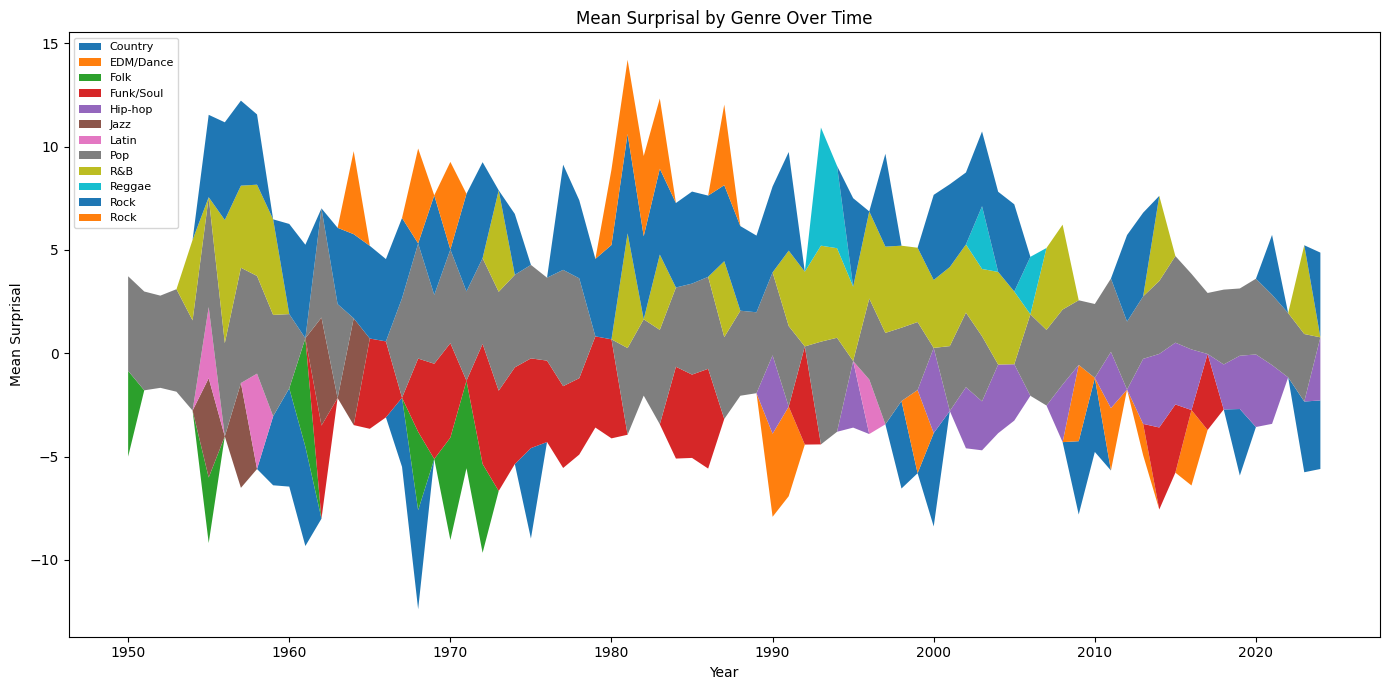

In [68]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Step 1: Extract year and aggregate by year + genre ---
merged_df["year"] = merged_df["year_position"].str[:4].astype(int)

yearly_genre = (
    merged_df.groupby(["year", "Genre (Broad 1)"])["mean_surprisal"]
    .mean()
    .reset_index()
)

# Pivot so genres are columns, years are rows
pivot_df = yearly_genre.pivot(index="year", columns="Genre (Broad 1)", values="mean_surprisal").fillna(0)

# --- Step 2: Plot streamgraph ---
years = pivot_df.index.values
genres = pivot_df.columns.tolist()
values = pivot_df.values.T  # shape: (n_genres, n_years)

fig, ax = plt.subplots(figsize=(14, 7))

ax.stackplot(years, values, labels=genres, baseline="wiggle")  # "wiggle" gives the stream shape

ax.legend(loc="upper left", fontsize=8)
ax.set_title("Mean Surprisal by Genre Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Surprisal")

plt.tight_layout()
plt.show()

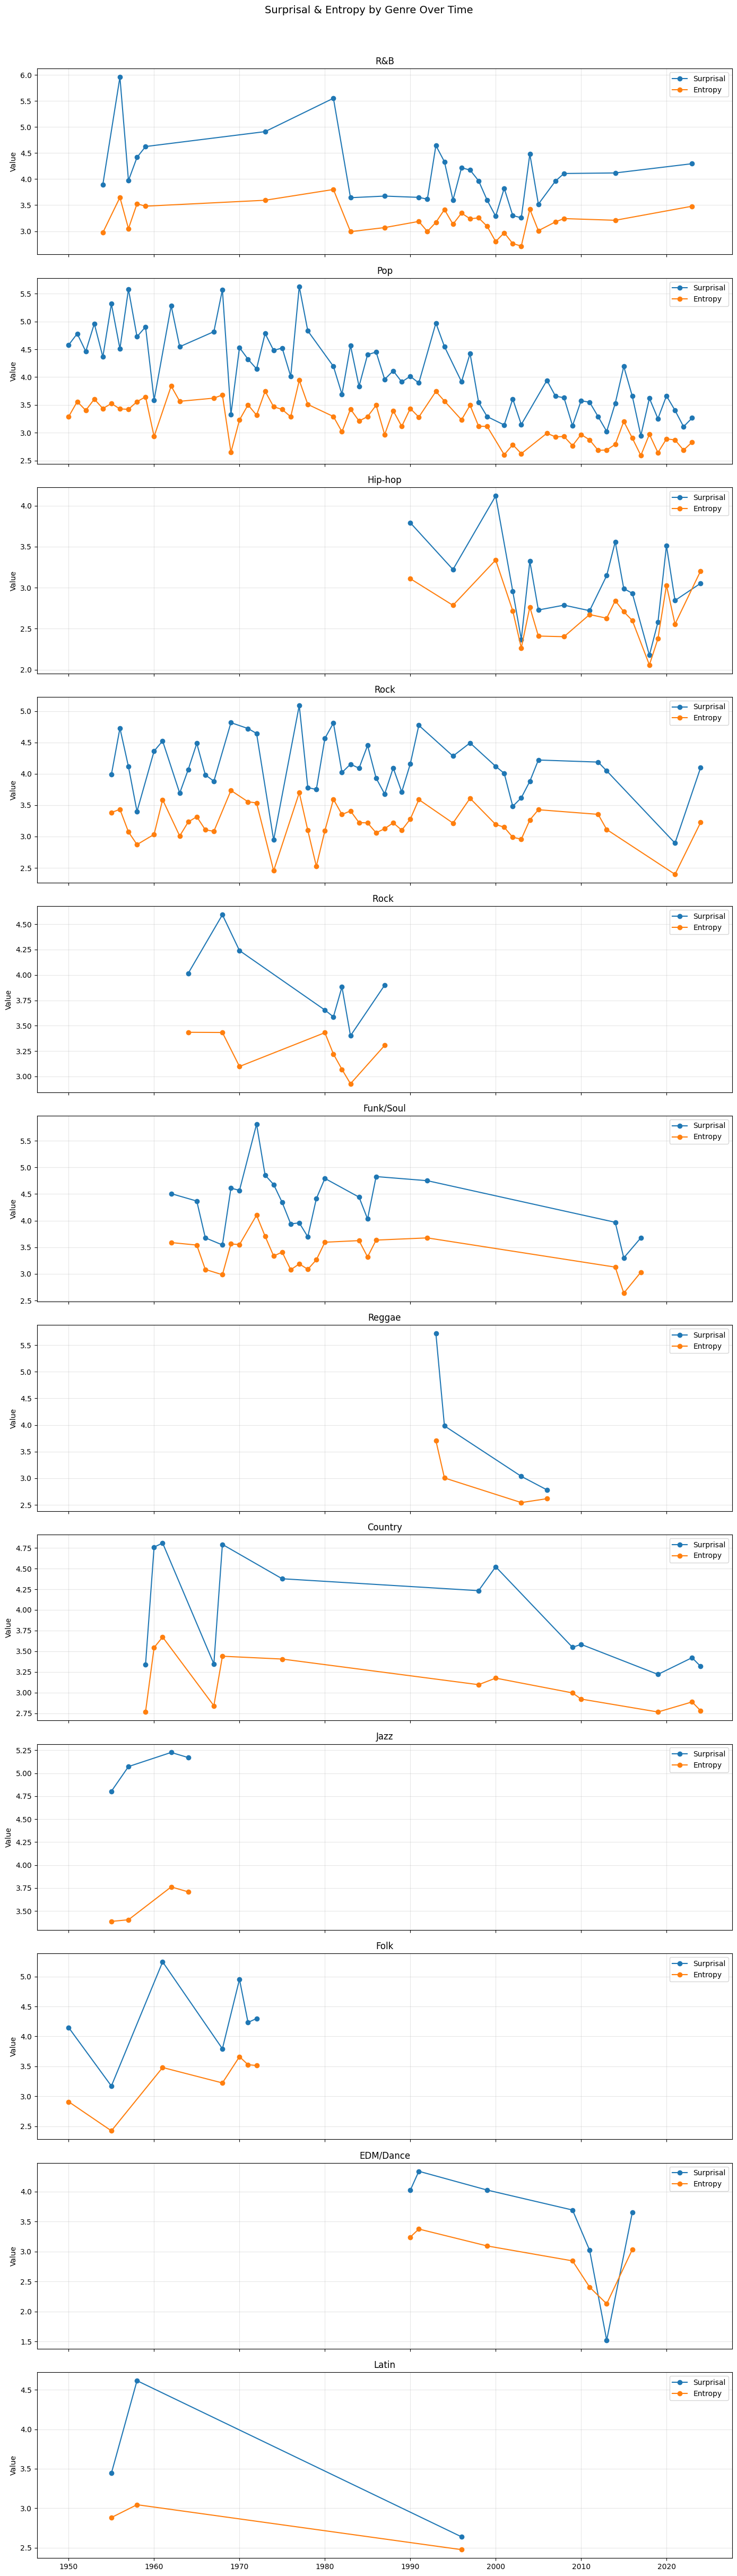

In [71]:
import matplotlib.pyplot as plt

genres = merged_df["Genre (Broad 1)"].dropna().unique()

fig, axes = plt.subplots(len(genres), 1, figsize=(14, 4 * len(genres)), sharex=True)

for ax, genre in zip(axes, genres):
    genre_df = merged_df[merged_df["Genre (Broad 1)"] == genre].copy()
    yearly = (
        genre_df.groupby("year")[["mean_surprisal", "mean_entropy"]]
        .mean()
        .reset_index()
        .sort_values("year")
    )

    ax.plot(yearly["year"], yearly["mean_surprisal"], label="Surprisal", marker="o")
    ax.plot(yearly["year"], yearly["mean_entropy"], label="Entropy", marker="o")
    ax.set_title(genre)
    ax.set_ylabel("Value")
    # ax.set_xlabel("Year")
    ax.legend()
    ax.grid(True, alpha=0.3)

# axes[-1].set_xlabel("Year")
plt.suptitle("Surprisal & Entropy by Genre Over Time", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()